In [4]:
import sklearn
print(sklearn.__version__)

1.9.0


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


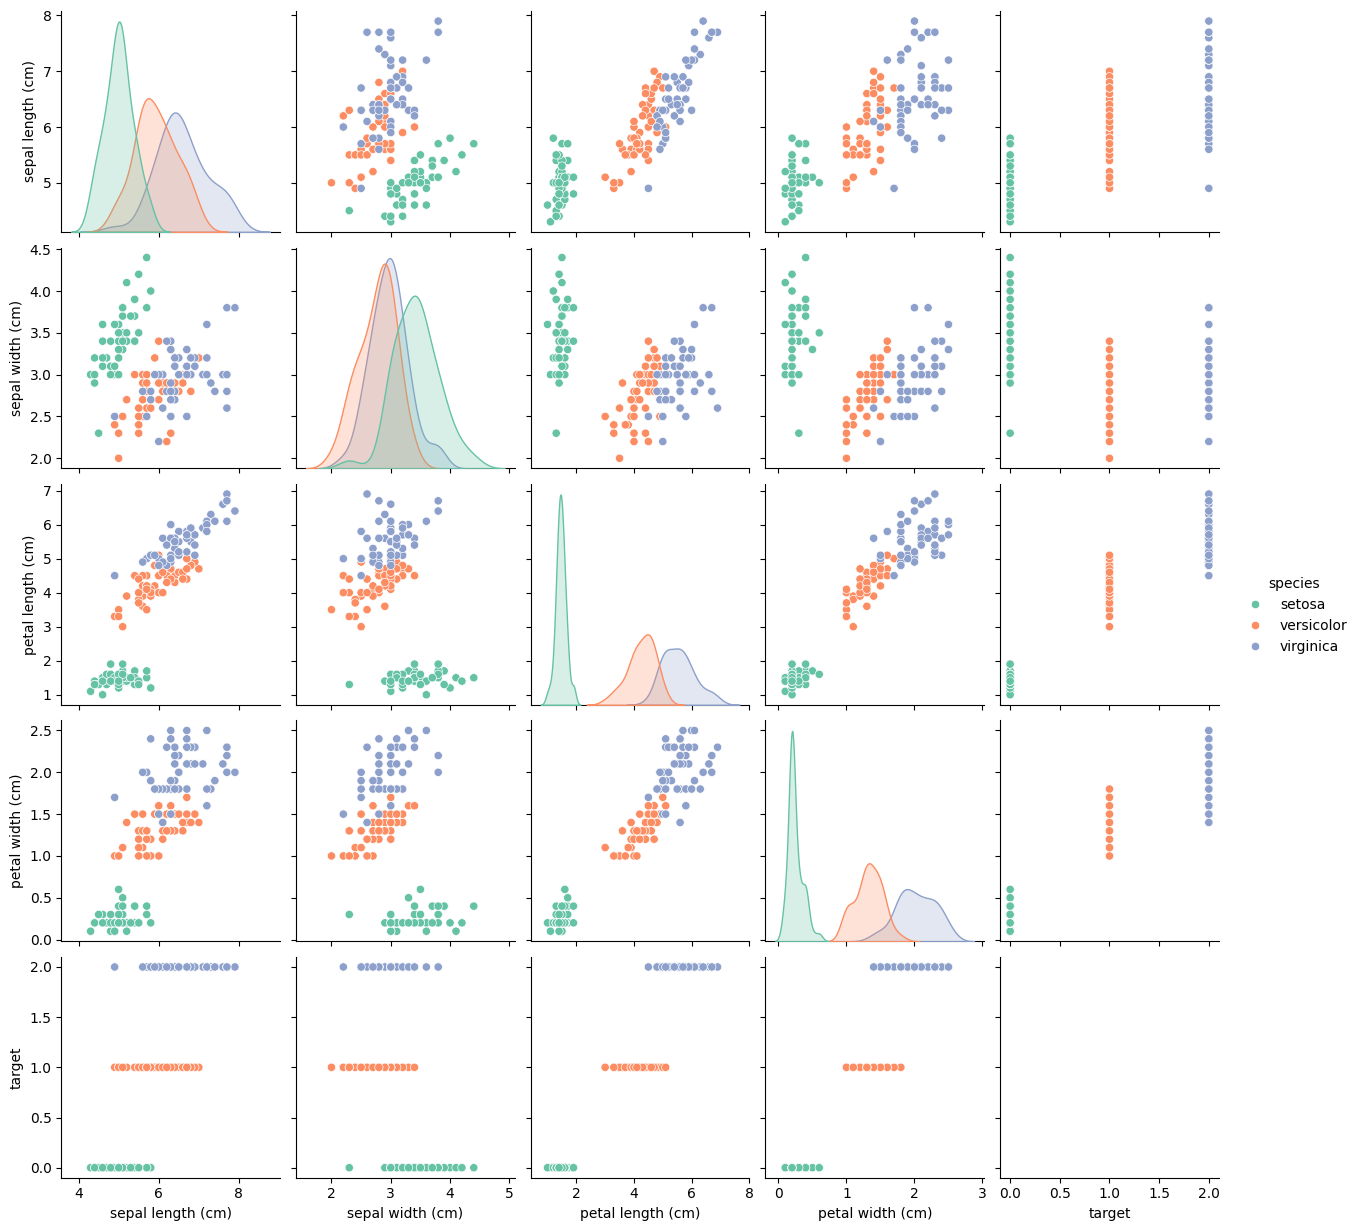

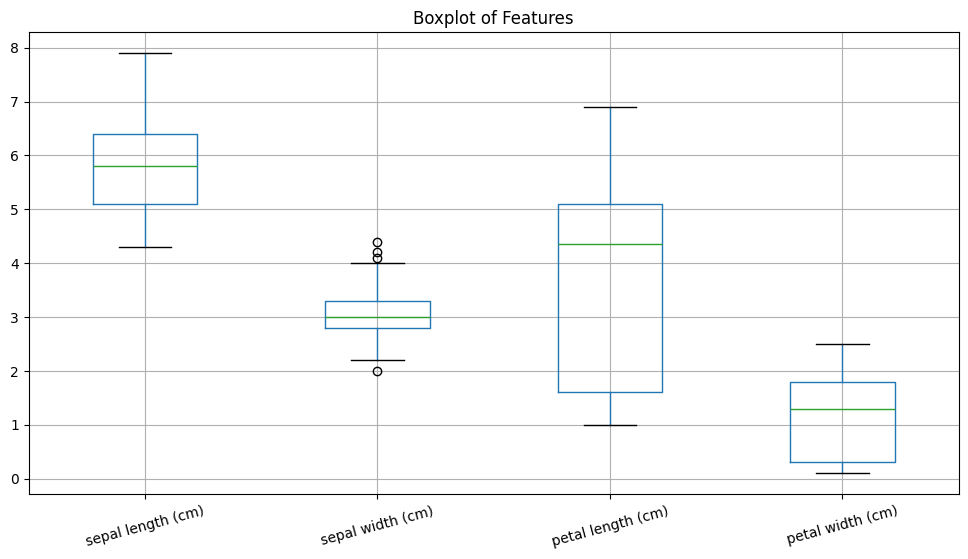

<Figure size 1000x800 with 0 Axes>

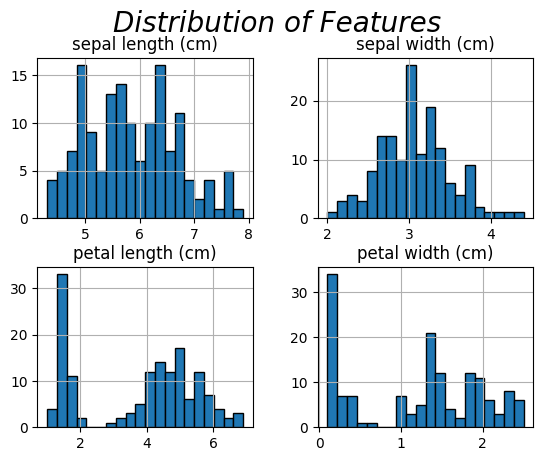

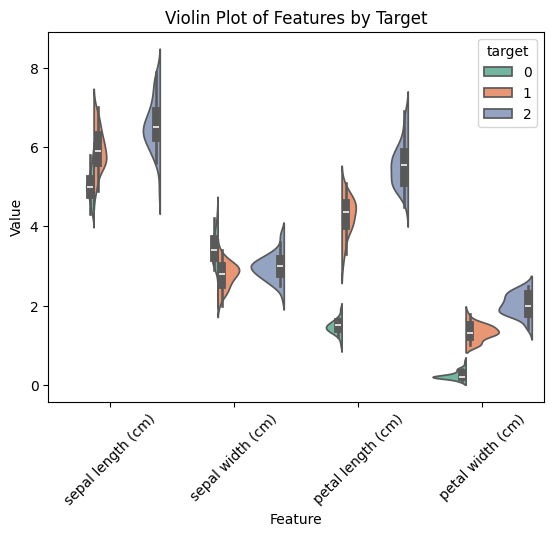

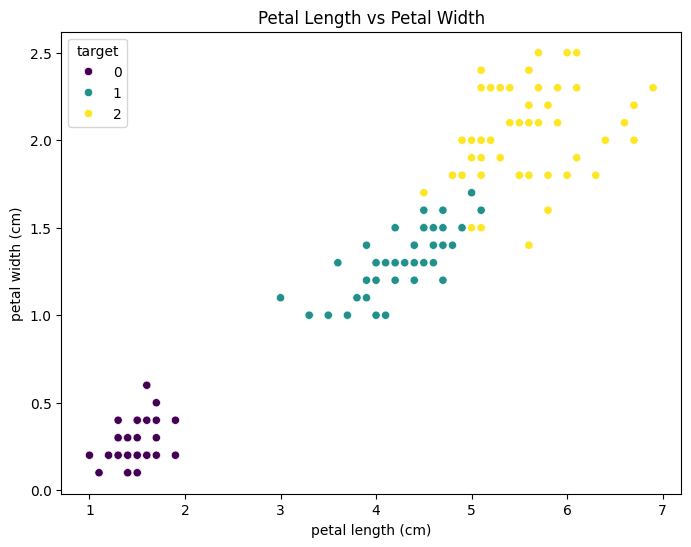

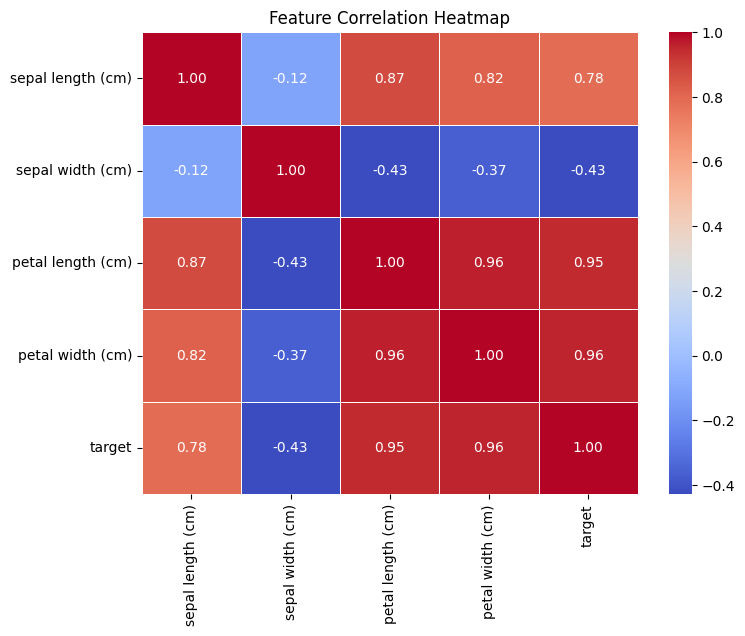

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Iris Dataset
iris = load_iris()

# Features and Target
X = iris.data
y = iris.target
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target
print(df.head())

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

df['species'] = df['target'].map({0:'setosa',1:'versicolor',2:'virginica'})
sns.pairplot(df, hue='species', palette='Set2')
plt.show()

#boxplot
plt.figure(figsize = (12,6))
df.drop(columns=['target']).boxplot()
plt.title("Boxplot of Features")
plt.xticks(rotation=15)
plt.show()

#histogram 
plt.figure(figsize=(10,8))
df.drop(columns=['target']).hist(bins=20, edgecolor='black')
plt.suptitle("Distribution of Features",fontsize=20,fontstyle='italic')
plt.show()

#violinplot
feature_cols = ['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']
df_melted = df.melt(id_vars=['target'], value_vars=feature_cols, var_name='Feature', value_name='Value')
sns.violinplot(x="Feature", y="Value", hue="target", data=df_melted, split=True, palette="Set2")
plt.xticks(rotation=45)
plt.title("Violin Plot of Features by Target")
plt.show()

#Scatterplot
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['petal length (cm)'], y=df['petal width (cm)'], hue=df["target"], 
palette="viridis")
plt.title("Petal Length vs Petal Width")
plt.show()

#heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()



In [3]:
# Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)
accuracy_log_reg = accuracy_score(y_test, y_pred_log) # Accuracy Score
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log) # Confusion Matrix
class_report_log_reg = classification_report(y_test, y_pred_log) # Classification Report
print(f"Logistic Regression Accuracy: {accuracy_log_reg:.2f}")
print("Confusion Matrix:")
print(conf_matrix_log_reg)
print("Classification Report:")
print(class_report_log_reg)

Logistic Regression Accuracy: 0.97
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [7]:
tree_clf = DecisionTreeClassifier()
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
accuracy_tree = accuracy_score(y_test, y_pred_tree)
conf_matrix_tree = confusion_matrix(y_test, y_pred_tree)
class_report_tree = classification_report(y_test, y_pred_tree)

print(f'Decision Tree Accuracy: {accuracy_tree:.2f}')
print('Confusion Matrix:')
print(conf_matrix_tree)
print('Classification Report:')
print(class_report_tree)


Decision Tree Accuracy: 0.97
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [8]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)
print(f'k-NN Accuracy: {accuracy_knn:.2f}')
print('Confusion Matrix:')
print(conf_matrix_knn)
print('Classification Report:')
print(class_report_knn)


k-NN Accuracy: 1.00
Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



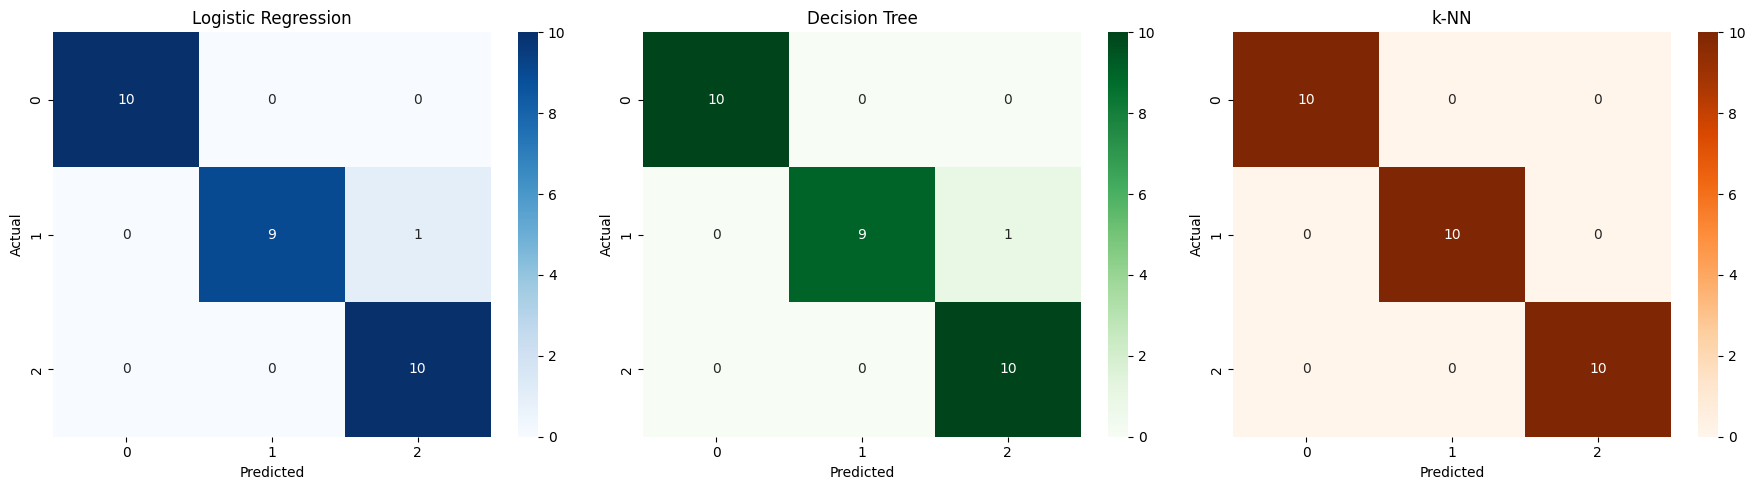

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Plot confusion matrix for Logistic Regression
sns.heatmap(conf_matrix_log_reg, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
# Plot confusion matrix for Decision Tree
sns.heatmap(conf_matrix_tree, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
# Plot confusion matrix for k-Nearest Neighbors
sns.heatmap(conf_matrix_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[2])
axes[2].set_title('k-NN')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')
# Display the plots
plt.tight_layout()
plt.show()

In [10]:
import pickle
 
# Save the model
with open('log_reg_model.pkl', 'wb') as model_file:
    pickle.dump(log_reg, model_file)
 
# Save the scaler  ← THIS WAS MISSING
with open('scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)
 
# Now load them back
with open('log_reg_model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)
 
with open('scaler.pkl', 'rb') as scaler_file:
    loaded_scaler = pickle.load(scaler_file)

In [16]:
import pickle
import pandas as pd
# ---------------------------
# Load the trained model and scaler
# ---------------------------
def load_model_and_scaler(model_filename='iris_model.pkl', 
    scaler_filename='iris_scaler.pkl'):
    """Loads the trained model and scaler from pickle files."""
    
    # Load the trained model from file (update with correct file name if needed)
    with open(r'C:\Users\inter\Desktop\Shrutika\Python-Practical\log_reg_model.pkl', 'rb') as model_file:
        model = pickle.load(model_file) # Deserialize model
    # Load the StandardScaler used during training
    with open(r'C:\Users\inter\Desktop\Shrutika\Python-Practical\scaler.pkl', 'rb') as scaler_file:
        scaler = pickle.load(scaler_file) # Deserialize scaler
    
    return model, scaler
# ---------------------------
# Preprocess input using the loaded scaler
# ---------------------------
def preprocess_input(input_data, scaler):
    # Convert the input dictionary to a single-row DataFrame
    input_df = pd.DataFrame([input_data])
    
    # Apply the same scaling used during training
    input_scaled = scaler.transform(input_df)
    
    return input_scaled
    # ---------------------------
    # Predict the Iris species
    # ---------------------------
def predict_iris_species(input_data):
    """Predicts the species of the Iris flower (Setosa, Versicolor, or Virginica)."""
    
    # Load the trained model and scaler
    model, scaler = load_model_and_scaler()
    
    # Preprocess input (apply scaling)
    input_scaled = preprocess_input(input_data, scaler)
    
    # Predict the species (returns 0, 1, or 2)
    prediction = model.predict(input_scaled)
    
    # Map numerical prediction to actual species name
    species_map = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}
    predicted_species = species_map[prediction[0]]
    
    return predicted_species
    # New input sample to classify
    

In [18]:
new_iris_data = {
    'sepal length (cm)': 5.1,
    'sepal width (cm)': 3.5,
    'petal length (cm)': 1.4,
    'petal width (cm)': 0.2
    }
    # Call the prediction function
result = predict_iris_species(new_iris_data)
print(f"The predicted species is: {result}")

The predicted species is: setosa


c:\Users\inter\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
